__Task: Based on rented bike count, the hour of the day, the day's temperature, humidity,
wind speed, rainfall, holidays, and many other factors, build a model to predict the bike
count required each hour for a stable supply of rental bikes.__

## 1. Load the dataset

__note:__ the CSV file isn’t saved using UTF-8 text encoding, which is the default encoding pandas expects when you run read_csv().

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Volumes/LaCie/Code/Aura/data/FloridaBikeRentals.csv", encoding="latin1")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## 2. Check for null values in any columns and handle the missing values

In [8]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

__Observations__

There are no null values in the dataset. Each variable contains complete data, so no missing value treatment is required before building the model.

| Features (X) | Target (y) |                       |
| ------------ | ---------- | --------------------- |
| Hour         |            |                       |
| Temperature  |            |                       |
| Humidity     |            |                       |
| Wind Speed   |            |                       |
| Rainfall     |            |                       |
| Holiday      |            |                       |
| Seasons      |            | **Rented Bike Count** |


The dataset contains several independent variables (x) such as hour of the day, temperature, humidity, wind speed, rainfall, seasons, and holidays. These features are used to predict the dependent variable, which is the rented bike count (y).

In [12]:
X = df.drop("Rented Bike Count", axis=1)
y = df["Rented Bike Count"]

#X = all columns except the target

# y = the column we want to predict

## 3. Convert Date columns to Date format and extract day, month, day of week, and weekdays/weekend from date column

In [14]:
# Convert the Date column to datetime format.
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [16]:
# extract features:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek

In [18]:
# Create weekend / weekday variable
df['weekend'] = df['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
df['weekday'] = df['day_of_week'].apply(lambda x: 1 if x <5 else 0)

## 4. Check correlation of features using heatmap

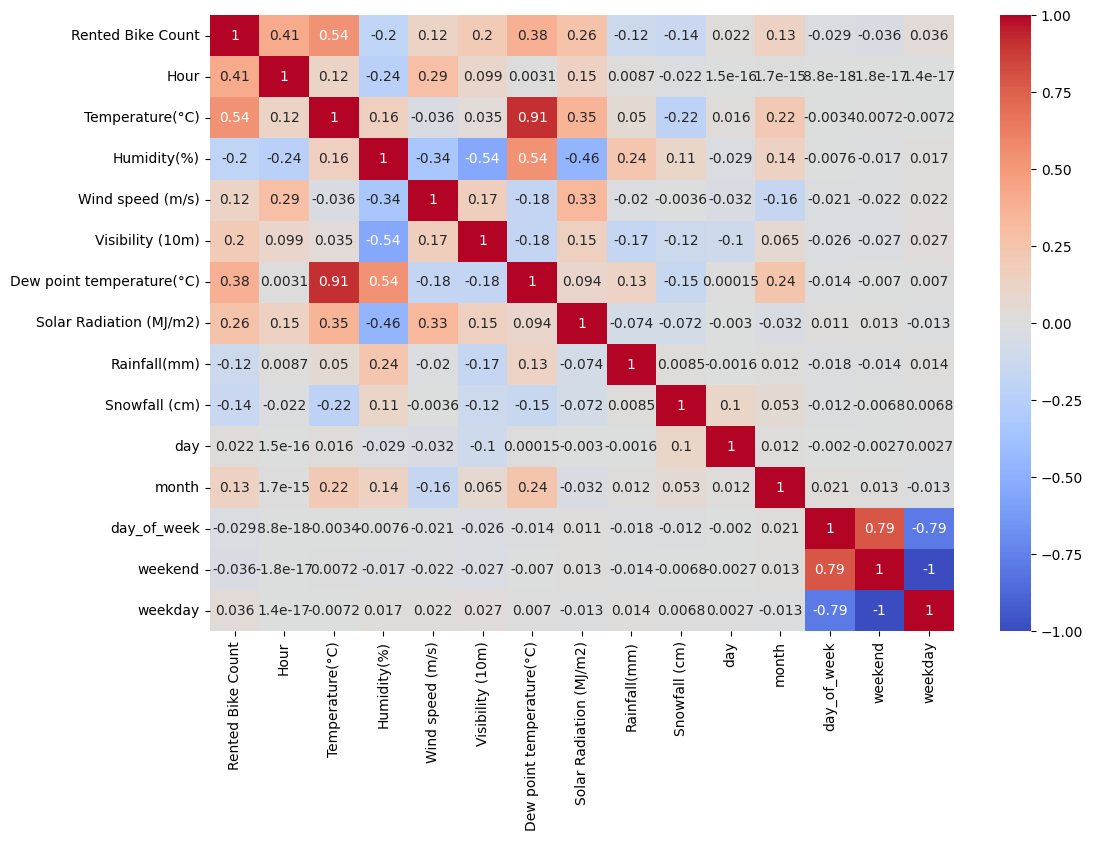

In [21]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Temperature ↑ → Bike demand ↑

Rainfall ↑ → Bike demand ↓

## 5. Plot the distribution plot of Rented Bike Count

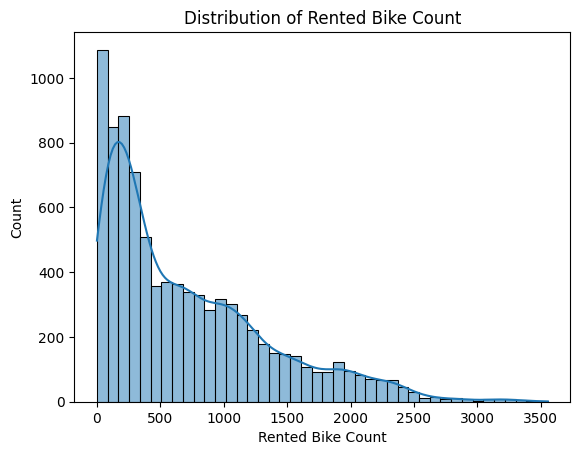

In [22]:
sns.histplot(df['Rented Bike Count'], kde=True)
plt.title("Distribution of Rented Bike Count")
plt.show()

Bike demand appears right-skewed, indicating most hours have moderate rentals with some high-demand periods.

## 6. Plot the histogram of all numerical features

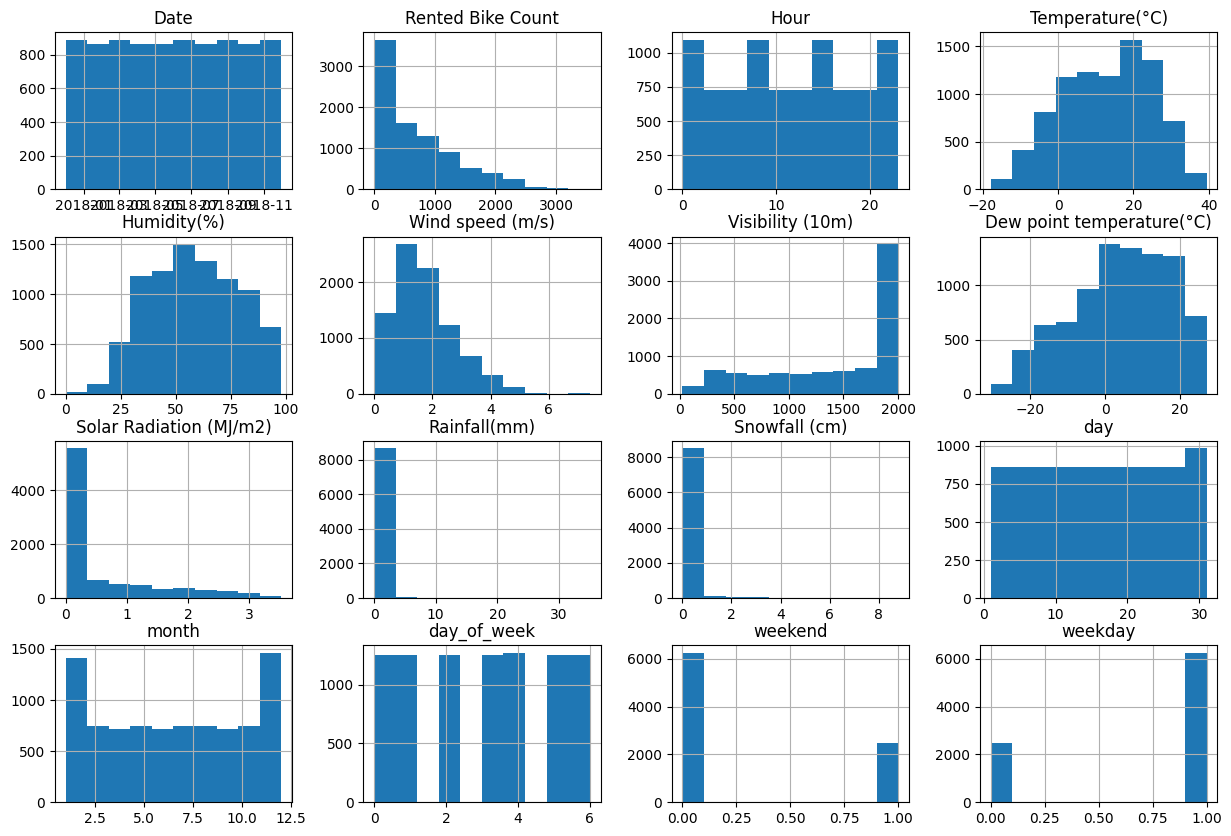

In [25]:
df.hist(figsize=(15,10))
plt.show()

## 7. Plot the box plot of Rented Bike Count against all the categorical features (Hint: Categorical features on X-axis and Rented Bike Count on Y-axis)

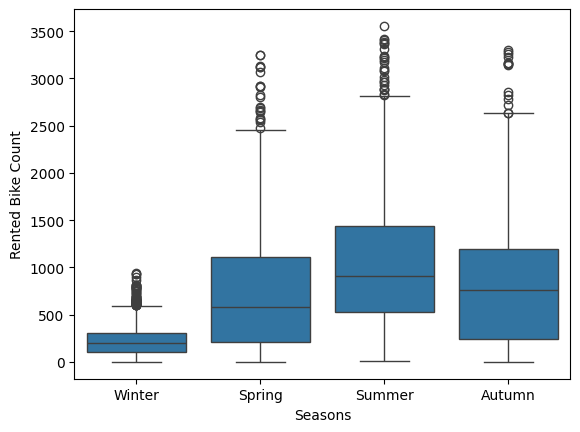

In [26]:
sns.boxplot(x='Seasons', y='Rented Bike Count', data=df)
plt.show()

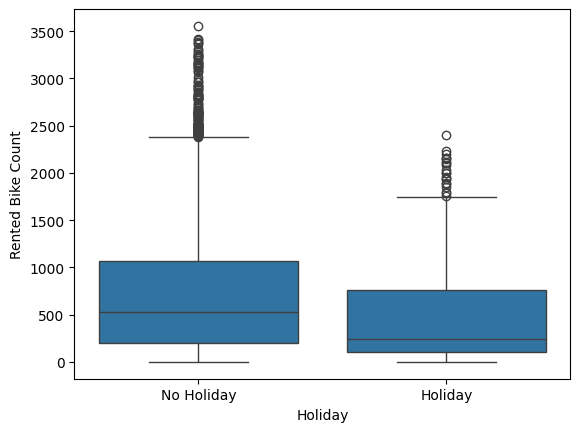

In [27]:
sns.boxplot(x='Holiday', y='Rented Bike Count', data=df)
plt.show()

Bike rentals are higher during summer and lower during winter.

# `Predicting Bike Rental Demand`

## 1.Plot the Seaborn catplot of Rented Bike Count against features like Hour, Holiday, Rainfall (mm), Snowfall (cm), weekdays, weekend, and give your inferences.

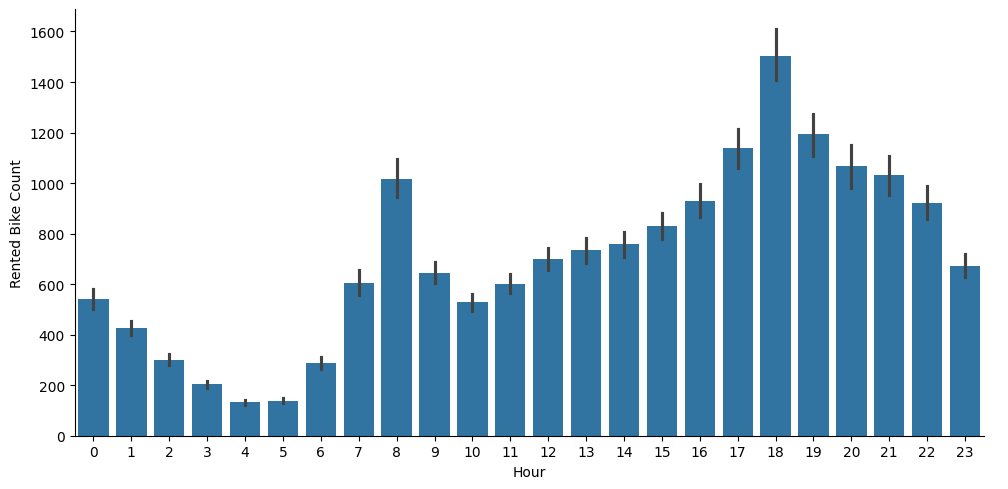

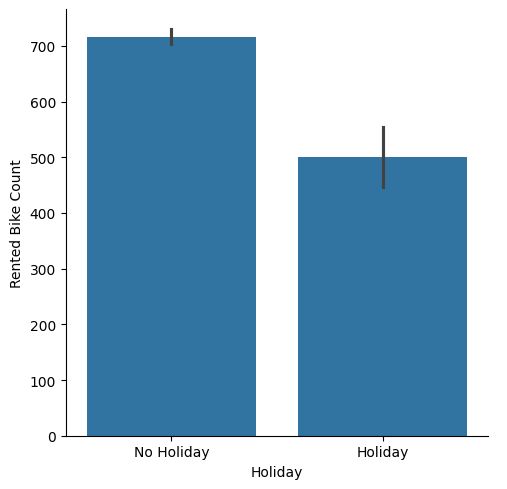

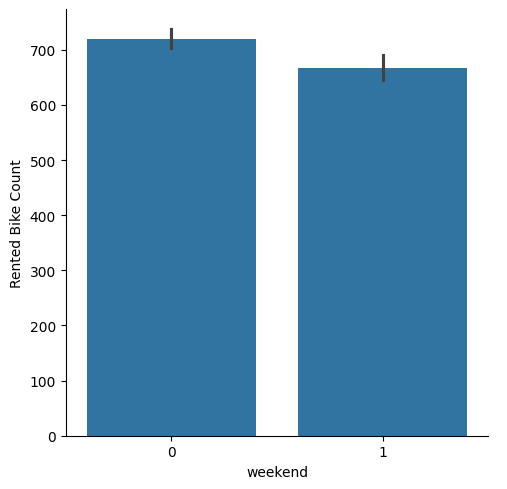

In [30]:
sns.catplot(x='Hour', y='Rented Bike Count', data=df, kind='bar', height=5, aspect=2)

sns.catplot(x='Holiday', y='Rented Bike Count', data=df, kind='bar')

sns.catplot(x='weekend', y='Rented Bike Count', data=df, kind='bar')



## 2. Encode the categorical features into numerical features.(Hint: use get_dummies())

In [31]:
df = pd.get_dummies(df, drop_first=True)

## 3. Identify the target variable and split the dataset into train and test with a ratio of 80:20 and random state 1

In [39]:
X = df.drop('Rented Bike Count', axis=1)
y = df['Rented Bike Count']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=1
)

In [42]:
df.columns


Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'day',
       'month', 'day_of_week', 'weekend', 'weekday', 'Seasons_Spring',
       'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday',
       'Functioning Day_Yes'],
      dtype='object')

In [43]:
df.dtypes

Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
day                            int32
month                          int32
day_of_week                    int32
weekend                        int64
weekday                        int64
Seasons_Spring                  bool
Seasons_Summer                  bool
Seasons_Winter                  bool
Holiday_No Holiday              bool
Functioning Day_Yes             bool
dtype: object

In [44]:
df = df.drop('Date', axis=1, errors='ignore')

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Perform Standard Scaling of the train dataset.

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [49]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Perform Linear Regression, Lasso Regression, and Ridge Regression to predict the bike count required each hour and compare the results.

In [50]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [51]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [52]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [54]:
### Compare Models


In [55]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [56]:
print("Linear Regression R2:", r2_score(y_test, y_pred_linear))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))

Linear Regression R2: 0.5511327852359081
Linear Regression RMSE: 430.7117275998397


In [57]:
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))
print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge Regression R2: 0.5511661142496074
Ridge Regression RMSE: 430.69573683121075


In [58]:
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))
print("Lasso Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso Regression R2: 0.5511824749252602
Lasso Regression RMSE: 430.6878870033637
